In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [19]:
from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
df.head()


Saving Dataset  (1).csv to Dataset  (1) (2).csv


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [20]:

print("Shape:", df.shape)
print("Columns:", df.columns)
print("Missing Values:\n", df.isnull().sum())
df.rename(columns={
    'Has Table booking': 'Has_Table_booking',
    'Has Online delivery': 'Has_Online_delivery',
    'Aggregate rating': 'Aggregate_rating',
    'Price range': 'Price_range'
}, inplace=True)

df[['Has_Table_booking', 'Has_Online_delivery', 'Aggregate_rating', 'Price_range']].head()


Shape: (9551, 21)
Columns: Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')
Missing Values:
 Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype

,Has_Table_booking,Has_Online_delivery,Aggregate_rating,Price_range
0,Yes,No,4.8,3
1,Yes,No,4.5,3
2,Yes,No,4.4,4
3,No,No,4.9,4
4,Yes,No,4.8,4


In [21]:
table_percent = df['Has_Table_booking'].value_counts(normalize=True) * 100
delivery_percent = df['Has_Online_delivery'].value_counts(normalize=True) * 100
print("Table Booking %:\n", table_percent)
print("\nOnline Delivery %:\n", delivery_percent)


Table Booking %:
 Has_Table_booking
No     87.875615
Yes    12.124385
Name: proportion, dtype: float64

Online Delivery %:
 Has_Online_delivery
No     74.337766
Yes    25.662234
Name: proportion, dtype: float64


In [22]:

df['Has_Table_booking'] = df['Has_Table_booking'].map({'Yes': 1, 'No': 0})
df['Has_Online_delivery'] = df['Has_Online_delivery'].map({'Yes': 1, 'No': 0})


rating_table = df.groupby('Has_Table_booking')['Aggregate_rating'].mean()
rating_delivery = df.groupby('Has_Online_delivery')['Aggregate_rating'].mean()

print("Avg Rating (Table Booking):\n", rating_table)
print("\nAvg Rating (Online Delivery):\n", rating_delivery)


Avg Rating (Table Booking):
 Has_Table_booking
0    2.559359
1    3.441969
Name: Aggregate_rating, dtype: float64

Avg Rating (Online Delivery):
 Has_Online_delivery
0    2.465296
1    3.248837
Name: Aggregate_rating, dtype: float64


Has_Online_delivery         0         1
Price_range                            
1                    1.809778  3.014979
2                    2.739683  3.227138
3                    3.706319  3.627737
4                    3.806754  3.930189


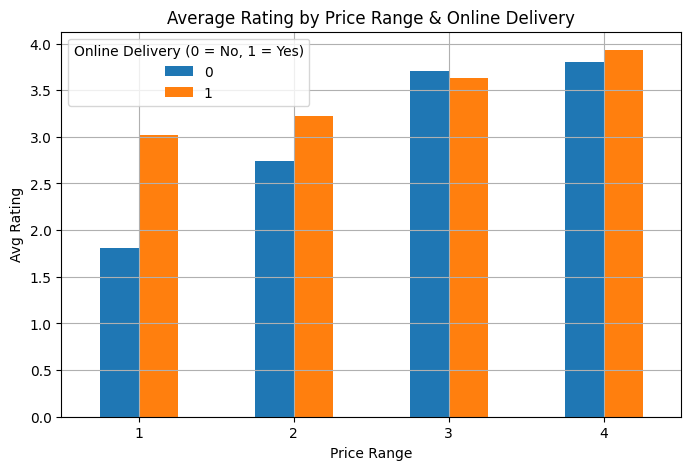

In [23]:

delivery_price_rating = df.groupby(['Price_range', 'Has_Online_delivery'])['Aggregate_rating'].mean().unstack()

print(delivery_price_rating)

delivery_price_rating.plot(kind='bar', figsize=(8,5))
plt.title("Average Rating by Price Range & Online Delivery")
plt.ylabel("Avg Rating")
plt.xlabel("Price Range")
plt.legend(title='Online Delivery (0 = No, 1 = Yes)')
plt.xticks(rotation=0)
plt.grid(True)
plt.show()
